In [38]:
import os
from dotenv import load_dotenv
import psycopg
import pandas as pd
import numpy as np
import mlflow
from catboost import CatBoostClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

TABLE_NAME = 'users_churn'
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = 'users_churn_with_mlxtend'# ваш код здесь #
RUN_NAME = "feature_selection"
REGISTRY_MODEL_NAME = 'users_churn_with_mlxtend'# ваш код здесь #
FS_ASSETS = "fs_assets"

In [39]:
# ============================================================
# MLflow connection + новый experiment
# ============================================================

MLFLOW_TRACKING_URI = (
    f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"
)

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print("Tracking URI:", mlflow.get_tracking_uri())


# ------------------------------------------------------------
# Получаем или создаём эксперимент
# ------------------------------------------------------------

experiment = mlflow.get_experiment_by_name(
    EXPERIMENT_NAME
)

if experiment is None:

    experiment_id = mlflow.create_experiment(
        name=EXPERIMENT_NAME
    )

    print("Создан новый эксперимент.")

else:

    experiment_id = experiment.experiment_id

    print("Эксперимент уже существует.")


# ------------------------------------------------------------
# Проверка
# ------------------------------------------------------------

experiment = mlflow.get_experiment(
    experiment_id
)

print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)
print("Artifact location:", experiment.artifact_location)

Tracking URI: http://127.0.0.1:5000
Эксперимент уже существует.
Experiment name: users_churn_with_mlxtend
Experiment ID: 9
Artifact location: s3://s3-student-mle-20260729-1a551ccfe6-freetrack/9


In [40]:
DB_DESTINATION_HOST = os.getenv("DB_DESTINATION_HOST")
DB_DESTINATION_PORT = os.getenv("DB_DESTINATION_PORT")
DB_DESTINATION_NAME = os.getenv("DB_DESTINATION_NAME")
DB_DESTINATION_USER = os.getenv("DB_DESTINATION_USER")
DB_DESTINATION_PASSWORD = os.getenv("DB_DESTINATION_PASSWORD")

load_dotenv()
connection = {
    "sslmode": "require",
    "target_session_attrs": "read-write"
}

postgres_credentials = {
    "host": DB_DESTINATION_HOST,
    "port": DB_DESTINATION_PORT,
    "dbname": DB_DESTINATION_NAME,
    "user": DB_DESTINATION_USER,
    "password": DB_DESTINATION_PASSWORD,
}

assert all(
    var_value != "" and var_value is not None
    for var_value in postgres_credentials.values()
)

connection.update(postgres_credentials)

TABLE_NAME = "users_churn"

with psycopg.connect(**connection) as conn:
    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")

        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

df.head()

,id,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,5768,8498-XXGWA,2014-09-01,NaT,Month-to-month,Yes,Mailed check,55.15,3673.15,DSL,...,Yes,No,No,No,Female,0,Yes,No,No,0
1,1,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,...,No,No,No,No,Female,0,Yes,No,None,0
2,5,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Fiber optic,...,No,No,No,No,Female,0,No,No,No,1
3,6,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Fiber optic,...,Yes,No,Yes,Yes,Female,0,No,No,Yes,1
4,7,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Fiber optic,...,No,No,Yes,No,Male,0,No,Yes,Yes,0


In [41]:
df["end_date_flag"] = (
    df["end_date"]
    .apply(lambda x: 0 if pd.isna(x) else 1)
)
cols_to_drop = [
    'begin_date',
    'end_date',
    'endDate',
    'customer_id',
    'gender',
    'senior_citizen',
    'contract_duration_months',
    'target',
    'id',
    'contract_duration_days'
]
full_data_set = df.drop(
    columns=cols_to_drop,
    errors="ignore"
)

display(full_data_set.head())

,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,partner,dependents,multiple_lines,end_date_flag
0,Month-to-month,Yes,Mailed check,55.15,3673.15,DSL,Yes,No,Yes,No,No,No,Yes,No,No,0
1,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,No,Yes,No,No,No,No,Yes,No,None,0
2,Month-to-month,Yes,Electronic check,70.70,151.65,Fiber optic,No,No,No,No,No,No,No,No,No,1
3,Month-to-month,Yes,Electronic check,99.65,820.50,Fiber optic,No,No,Yes,No,Yes,Yes,No,No,Yes,1
4,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Fiber optic,No,Yes,No,No,Yes,No,No,Yes,Yes,0


In [42]:
TEST_SIZE = 0.25

X = full_data_set.drop(
    columns=["end_date_flag"]
)

y = full_data_set["end_date_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=TEST_SIZE,
    random_state=42
)

In [43]:
# Копия
X_train_encoded = X_train.copy()

# Удаляем ID и даты
X_train_encoded = X_train_encoded.drop(
    columns=[
        "customer_id",
        "begin_date",
        "end_date",
        "endDate"
    ],
    errors="ignore"
)

# Категориальные и числовые признаки
cat_cols = X_train_encoded.select_dtypes(
    include=["object", "category"]
).columns

num_cols = X_train_encoded.select_dtypes(
    include=["number"]
).columns

# Заполняем пропуски
for col in cat_cols:
    X_train_encoded[col] = X_train_encoded[col].fillna("Unknown")

for col in num_cols:
    X_train_encoded[col] = X_train_encoded[col].fillna(
        X_train_encoded[col].median()
    )

# Кодируем категории
X_train_encoded = pd.get_dummies(
    X_train_encoded,
    columns=cat_cols,
    drop_first=False,
    dtype=int
)

print("Размер:", X_train_encoded.shape)
print("NaN:", X_train_encoded.isna().sum().sum())
print(
    "Строковые:",
    X_train_encoded.select_dtypes(exclude="number").columns.tolist()
)

Размер: (5282, 39)
NaN: 0
Строковые: []


In [44]:
# Быстрый Random Forest для предварительного отбора
rf_preselection = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_preselection.fit(
    X_train_encoded,
    y_train
)

# Важность признаков
importance = pd.Series(
    rf_preselection.feature_importances_,
    index=X_train_encoded.columns
).sort_values(ascending=False)

# Оставляем TOP-20
preselected_features = importance.head(20).index.tolist()

X_train_selected = X_train_encoded[preselected_features]

print("Было признаков:", X_train_encoded.shape[1])
print("Оставили:", X_train_selected.shape[1])

print("\nTOP-20:")
for feature in preselected_features:
    print(feature)

Было признаков: 39
Оставили: 20

TOP-20:
total_charges
monthly_charges
type_Month-to-month
payment_method_Electronic check
online_security_No
tech_support_No
internet_service_Fiber optic
online_backup_No
type_Two year
device_protection_No
paperless_billing_No
multiple_lines_No
paperless_billing_Yes
partner_No
partner_Yes
multiple_lines_Yes
dependents_Yes
payment_method_Credit card (automatic)
payment_method_Bank transfer (automatic)
dependents_No


In [45]:
estimator = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

# Forward
sfs = SFS(
    estimator,
    k_features=10,
    forward=True,
    floating=False,
    scoring="roc_auc",
    cv=4,
    n_jobs=-1
)

# Backward
sbs = SFS(
    estimator,
    k_features=10,
    forward=False,
    floating=False,
    scoring="roc_auc",
    cv=4,
    n_jobs=-1
)

print("Запускаем SFS...")

sfs = sfs.fit(
    X_train_selected,
    y_train
)

top_sfs = sfs.k_feature_names_

print("\nSFS завершён")
print("Features:")
print(top_sfs)
print("CV Score:")
print(sfs.k_score_)


print("\nЗапускаем SBS...")

sbs = sbs.fit(
    X_train_selected,
    y_train
)

top_sbs = sbs.k_feature_names_

print("\nSBS завершён")
print("Features:")
print(top_sbs)
print("CV Score:")
print(sbs.k_score_)

Запускаем SFS...

SFS завершён
Features:
('type_Month-to-month', 'payment_method_Electronic check', 'online_security_No', 'internet_service_Fiber optic', 'online_backup_No', 'type_Two year', 'multiple_lines_No', 'multiple_lines_Yes', 'payment_method_Credit card (automatic)', 'payment_method_Bank transfer (automatic)')
CV Score:
0.8007942990571857

Запускаем SBS...

SBS завершён
Features:
('total_charges', 'monthly_charges', 'type_Month-to-month', 'online_security_No', 'tech_support_No', 'type_Two year', 'paperless_billing_No', 'partner_Yes', 'multiple_lines_Yes', 'dependents_No')
CV Score:
0.80856087593201


In [46]:
interc_features = list(
    set(top_sfs) & set(top_sbs)
)

union_features = list(
    set(top_sfs) | set(top_sbs)
)

print("Пересечение:")
print(interc_features)

print("\nОбъединение:")
print(union_features)

Пересечение:
['online_security_No', 'multiple_lines_Yes', 'type_Two year', 'type_Month-to-month']

Объединение:
['internet_service_Fiber optic', 'payment_method_Electronic check', 'tech_support_No', 'payment_method_Credit card (automatic)', 'payment_method_Bank transfer (automatic)', 'monthly_charges', 'multiple_lines_No', 'type_Two year', 'online_backup_No', 'online_security_No', 'type_Month-to-month', 'paperless_billing_No', 'partner_Yes', 'dependents_No', 'multiple_lines_Yes', 'total_charges']


In [47]:
sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sbs_df = pd.DataFrame.from_dict(sbs.get_metric_dict()).T

In [48]:
# Папка создастся только если её ещё нет
os.makedirs(FS_ASSETS, exist_ok=True)

# Сохраняем результаты SFS и SBS
sfs_df.to_csv(
    f"{FS_ASSETS}/sfs.csv",
    index=False
)

sbs_df.to_csv(
    f"{FS_ASSETS}/sbs.csv",
    index=False
)

print("Файлы в папке:")
print(os.listdir(FS_ASSETS))

Файлы в папке:
['sbs.csv', 'sfs.csv']


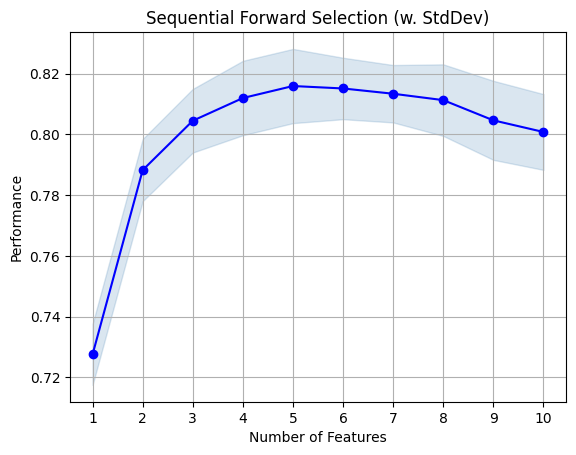

<Figure size 640x480 with 0 Axes>

In [57]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig("FS_ASSETS/sfs.png") 

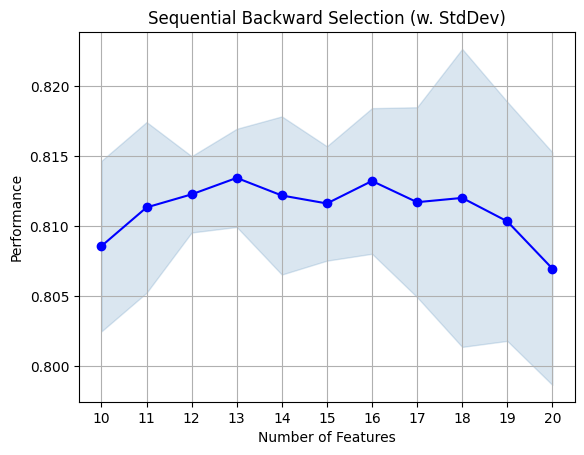

<Figure size 640x480 with 0 Axes>

In [56]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sbs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Backward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig("FS_ASSETS/sbs.png")

In [58]:
os.makedirs(FS_ASSETS, exist_ok=True)

print("FS_ASSETS =", FS_ASSETS)


# ============================================================
# 2. Сохраняем SFS CSV
# ============================================================

sfs_df.to_csv(
    f"{FS_ASSETS}/sfs.csv",
    index=False
)


# ============================================================
# 3. Сохраняем SBS CSV
# ============================================================

sbs_df.to_csv(
    f"{FS_ASSETS}/sbs.csv",
    index=False
)


# ============================================================
# 4. Сохраняем график SFS
# ============================================================

plot_sfs(
    sfs.get_metric_dict(),
    kind="std_dev"
)

plt.title("Sequential Forward Selection (w. StdDev)")
plt.grid()

plt.savefig(
    f"{FS_ASSETS}/sfs.png",
    bbox_inches="tight"
)

plt.close()


# ============================================================
# 5. Сохраняем график SBS
# ============================================================

plot_sfs(
    sbs.get_metric_dict(),
    kind="std_dev"
)

plt.title("Sequential Backward Selection (w. StdDev)")
plt.grid()

plt.savefig(
    f"{FS_ASSETS}/sbs.png",
    bbox_inches="tight"
)

plt.close()


# ============================================================
# 6. Проверяем четыре обязательных файла
# ============================================================

required_files = [
    "sbs.csv",
    "sbs.png",
    "sfs.csv",
    "sfs.png"
]

print("\nФайлы в fs_assets:")

for file_name in required_files:

    path = os.path.join(
        FS_ASSETS,
        file_name
    )

    print(
        file_name,
        "OK" if os.path.exists(path) else "MISSING"
    )

FS_ASSETS = fs_assets

Файлы в fs_assets:
sbs.csv OK
sbs.png OK
sfs.csv OK
sfs.png OK


In [59]:
interc_features = list(set(top_sbs) & set(top_sfs))
union_features = list(set(top_sbs) | set(top_sfs))

In [60]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

experiment_id = experiment.experiment_id

print("Experiment:", experiment.name)
print("Experiment ID:", experiment_id)

with mlflow.start_run(
    run_name=f"{RUN_NAME}_intersection_and_union",
    experiment_id=experiment_id
) as run:

    run_id = run.info.run_id

    mlflow.log_artifacts(FS_ASSETS)

    print("Artifacts uploaded successfully")
    print("Run ID:", run_id)


Experiment: users_churn_with_mlxtend
Experiment ID: 9
Artifacts uploaded successfully
Run ID: f8c1afc9f7074af5a3bfd3240aea3863


In [62]:
# ============================================================
# Настройки
# ============================================================

MODEL_NAME = "users_churn_with_mlxtend"

EXPERIMENT_INTERC = "feature_selection_intersection"
EXPERIMENT_UNION = "feature_selection_union"


# ============================================================
# Функция получения / создания эксперимента
# ============================================================

def get_or_create_experiment(name):

    experiment = mlflow.get_experiment_by_name(name)

    if experiment is None:
        experiment_id = mlflow.create_experiment(name)
    else:
        experiment_id = experiment.experiment_id

    return experiment_id


# ============================================================
# Создаём эксперименты
# ============================================================

experiment_id_interc = get_or_create_experiment(
    EXPERIMENT_INTERC
)

experiment_id_union = get_or_create_experiment(
    EXPERIMENT_UNION
)

print(
    "Intersection experiment ID:",
    experiment_id_interc
)

print(
    "Union experiment ID:",
    experiment_id_union
)


# ============================================================
# INTERSECTION
# ============================================================

with mlflow.start_run(
    experiment_id=experiment_id_interc,
    run_name=MODEL_NAME
) as run:

    run_id_interc = run.info.run_id

    model_interc = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model_interc.fit(
        X_train_encoded[list(interc_features)],
        y_train
    )

    mlflow.sklearn.log_model(
        sk_model=model_interc,
        artifact_path="model"
    )

    registered_interc = mlflow.register_model(
        model_uri=f"runs:/{run_id_interc}/model",
        name=MODEL_NAME
    )

    model_version_id_interc = int(
        registered_interc.version
    )


# ============================================================
# UNION
# ============================================================

with mlflow.start_run(
    experiment_id=experiment_id_union,
    run_name=MODEL_NAME
) as run:

    run_id_union = run.info.run_id

    model_union = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model_union.fit(
        X_train_encoded[list(union_features)],
        y_train
    )

    mlflow.sklearn.log_model(
        sk_model=model_union,
        artifact_path="model"
    )

    registered_union = mlflow.register_model(
        model_uri=f"runs:/{run_id_union}/model",
        name=MODEL_NAME
    )

    model_version_id_union = int(
        registered_union.version
    )


# ============================================================
# Переменные для тренажёра
# ============================================================

registred_model_name = MODEL_NAME

model_registred_name_interc = MODEL_NAME
model_registred_name_union = MODEL_NAME

run_name_interc = MODEL_NAME
run_name_union = MODEL_NAME


# ============================================================
# Вывод
# ============================================================

print("\n" + "=" * 60)
print("ЗНАЧЕНИЯ ДЛЯ ТРЕНАЖЁРА")
print("=" * 60)

print(
    "registred_model_name =",
    repr(registred_model_name)
)

print(
    "model_registred_name_interc =",
    repr(model_registred_name_interc)
)

print(
    "model_version_id_interc =",
    model_version_id_interc
)

print(
    "run_name_interc =",
    repr(run_name_interc)
)

print(
    "run_id_interc =",
    repr(run_id_interc)
)

print(
    "model_registred_name_union =",
    repr(model_registred_name_union)
)

print(
    "model_version_id_union =",
    model_version_id_union
)

print(
    "run_name_union =",
    repr(run_name_union)
)

print(
    "run_id_union =",
    repr(run_id_union)
)

Intersection experiment ID: 10
Union experiment ID: 11


Registered model 'users_churn_with_mlxtend' already exists. Creating a new version of this model...
2026/09/15 18:20:13 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: users_churn_with_mlxtend, version 3
Created version '3' of model 'users_churn_with_mlxtend'.
Registered model 'users_churn_with_mlxtend' already exists. Creating a new version of this model...
2026/09/15 18:20:19 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: users_churn_with_mlxtend, version 4



ЗНАЧЕНИЯ ДЛЯ ТРЕНАЖЁРА
registred_model_name = 'users_churn_with_mlxtend'
model_registred_name_interc = 'users_churn_with_mlxtend'
model_version_id_interc = 3
run_name_interc = 'users_churn_with_mlxtend'
run_id_interc = '8c57aa45b5cc4c0b95292d58407ed06d'
model_registred_name_union = 'users_churn_with_mlxtend'
model_version_id_union = 4
run_name_union = 'users_churn_with_mlxtend'
run_id_union = 'f92836e88cee43c69cd19c4b7078c5f9'


Created version '4' of model 'users_churn_with_mlxtend'.
